In [2]:
import gymnasium as gym

# Initialise the environment
env = gym.make("LunarLander-v3", render_mode="human")

# Reset the environment to generate the first observation
observation, info = env.reset(seed=42)
for _ in range(1000):
    # this is where you would insert your policy
    action = env.action_space.sample()

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        observation, info = env.reset()

env.close()

### Maze Debugging

In [7]:
from pyamaze import maze
import pandas as pd
import tkinter as tk
import matplotlib.pyplot as plt

In [ ]:

tk.Tk.state = lambda self, s=None: self.wm_state('normal' if s == 'zoomed' else s)
def generate_df_maze(rows=20, cols=20, lp=80):
    # Create a Pyamaze maze
    m = maze(rows, cols)
    m.CreateMaze(loopPercent=lp)  # No loops to match a grid-like maze

    # List to store cell data
    maze_data = []
    for y in range(1, rows + 1):
        for x in range(1, cols + 1):
            cell = (x, y)
            cell_walls = m.maze_map[cell]  # Get wall info for each cell

            E = 1 if cell_walls['E'] else 0
            W = 1 if cell_walls['W'] else 0
            N = 1 if cell_walls['N'] else 0
            S = 1 if cell_walls['S'] else 0

            maze_data.append([f"({x},{y})", E, W, N, S])

    df = pd.DataFrame(maze_data, columns=["  cell  ", "E", "W", "N", "S"])
    if '  cell  ' in df.columns:
        df[['row', 'col']] = (
            df['  cell  '].astype(str)
            .str.replace(r'[()]', '', regex=True)
            .str.split(',', expand=True)
            .astype(int)
        )
    return df, m

In [3]:
# df_maze, m = generate_df_maze(
#             5,
#             5,
#             40
#         )
df_maze = pd.read_csv("data/rl_maze.csv")

In [14]:
m.run()

In [37]:
df_maze.iloc[44]

  cell      (5,5)
E               1
W               0
N               1
S               1
row             5
col             5
Name: 44, dtype: object

In [4]:
import networkx as nx
def _build_graph(df_maze):
        G = nx.Graph()
        for _, row in df_maze.iterrows():
            r, c = int(row['row']), int(row['col'])
            G.add_node((r, c))
            if row['E'] == 1:
                G.add_edge((r, c), (r, c+1))
            if row['W'] == 1:
                G.add_edge((r, c), (r, c - 1))
            if row['N'] == 1:
                G.add_edge((r, c), (r - 1, c))
            if row['S'] == 1:
                G.add_edge((r, c), (r + 1,c))
        return G

In [5]:
G = _build_graph(df_maze)

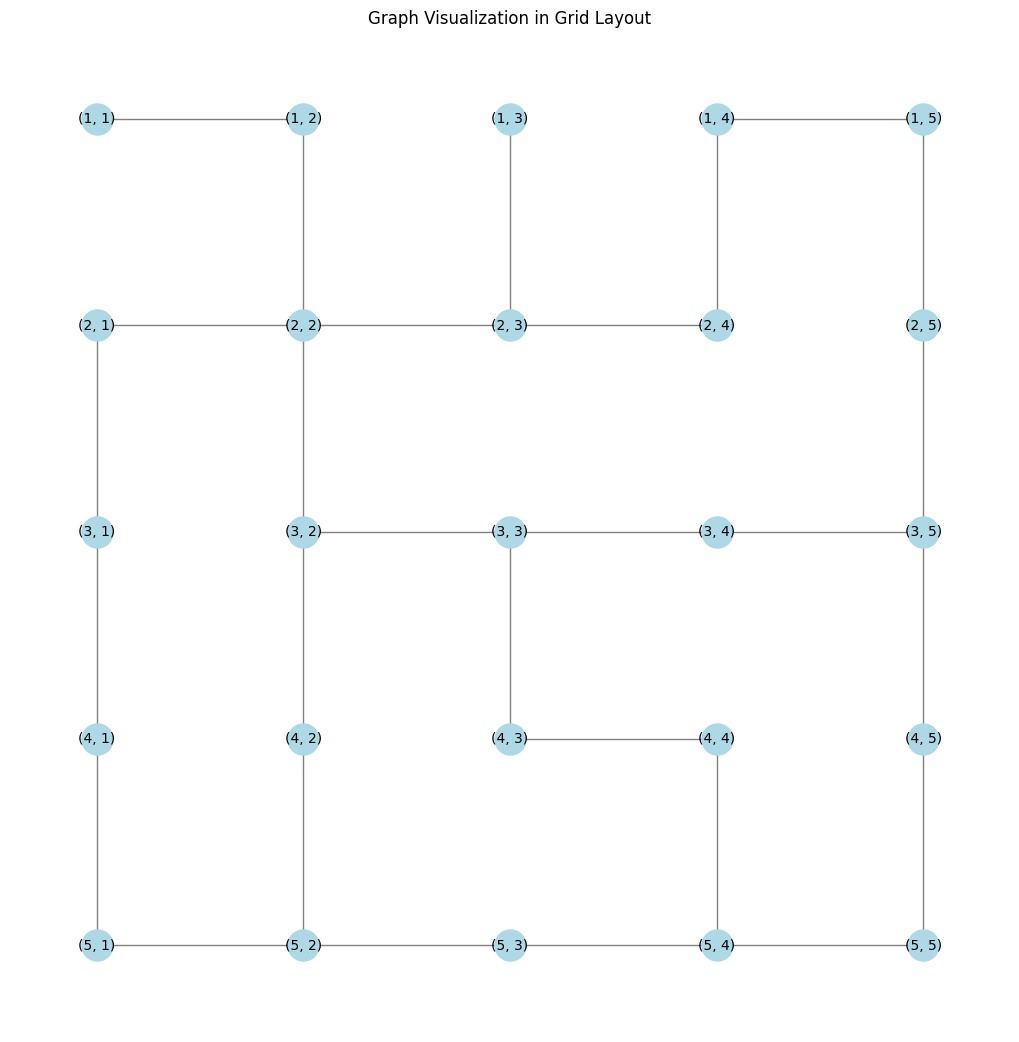

In [8]:
# Arrange nodes in a grid layout
pos = {(row['col'], row['row']): (row['row'], -row['col']) for _, row in df_maze.iterrows()}

# Draw the graph
plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10, edge_color='gray')
plt.title("Graph Visualization in Grid Layout")
plt.show()

In [34]:
# Print the edges of the center node
max_row = df_maze['row'].max()
max_col = df_maze['col'].max()
center_row = max_row // 2
center_col = max_col // 2
center_node = (center_col, center_row)
edges = G.edges(center_node)
print(f"Edges of the center node {center_node}: {list(edges)}")

Edges of the center node (np.int64(5), np.int64(5)): [((np.int64(5), np.int64(5)), (4, 5)), ((np.int64(5), np.int64(5)), (5, 6)), ((np.int64(5), np.int64(5)), (6, 5))]


In [18]:
df_maze.to_csv("data/rl_maze.csv", index=False)

## Plotting the Training Log

| Event                            | Reward        |
|----------------------------------|---------------|
| Reaching task                    | **+50.0**     |
| Completing all tasks             | **+50.0**     |
| Step taken                       | **–0.1**      |
| ❌ Attempting invalid move       | **-10000000** ← **(Bug: penalty intended but bonus given)** |
| Battery usage                    | _Ignored_ (commented out) |


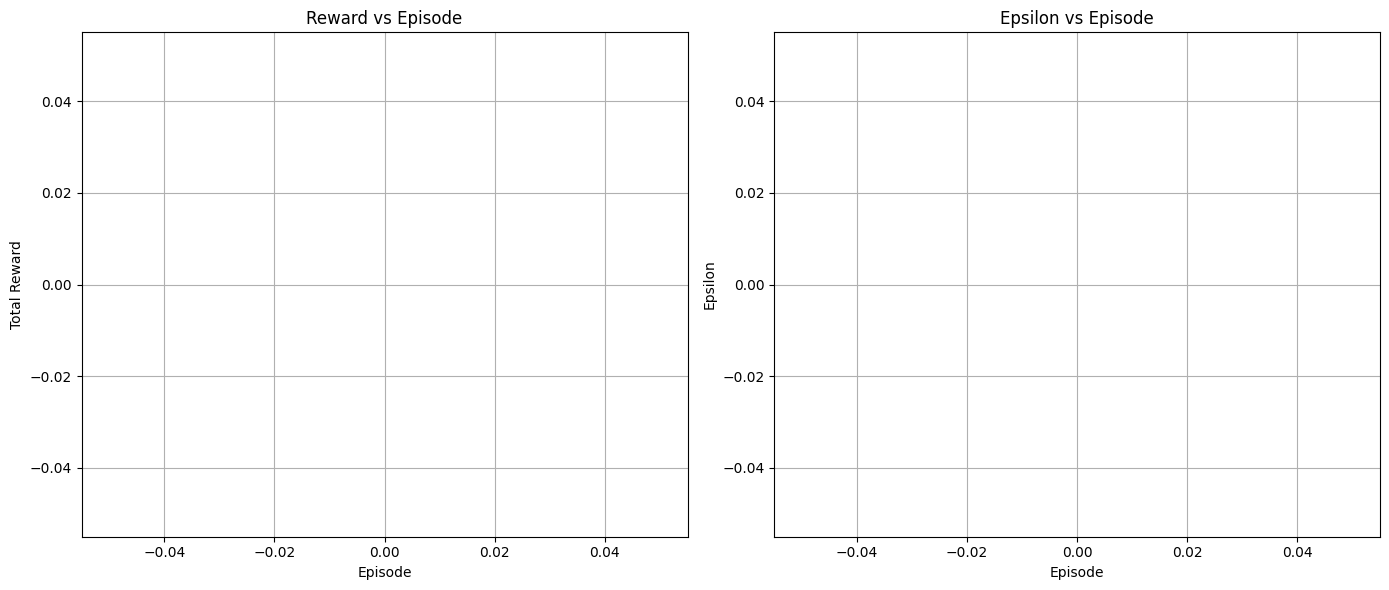

In [9]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load the text file
log_path = Path("tmp.txt")
with open(log_path, "r") as f:
    lines = f.readlines()

# Extract Episode, Reward, and Epsilon using regex
data = []
pattern = re.compile(r"Episode (\d+)/\d+, Reward: ([\-\d\.]+), Eps: ([\d\.]+)")
for line in lines:
    match = pattern.search(line)
    if match:
        episode = int(match.group(1))
        reward = float(match.group(2))
        epsilon = float(match.group(3))
        data.append((episode, reward, epsilon))

# Create a DataFrame
df = pd.DataFrame(data, columns=["Episode", "Reward", "Epsilon"])

# Plotting
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(df["Episode"], df["Reward"], label="Reward", color="blue")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward vs Episode")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(df["Episode"], df["Epsilon"], label="Epsilon", color="green")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon vs Episode")
plt.grid(True)

plt.tight_layout()
plt.show()


| Event                            | Reward        |
|----------------------------------|---------------|
| Reaching task                    | **+50.0**     |
| Moving towards the task             | **+5*distance**     |
| Step taken                       | **–1**      |
| ❌ Attempting invalid move       | **-20** ← **(Bug: penalty intended but bonus given)** |
| Battery usage                    | _Ignored_ (commented out) |


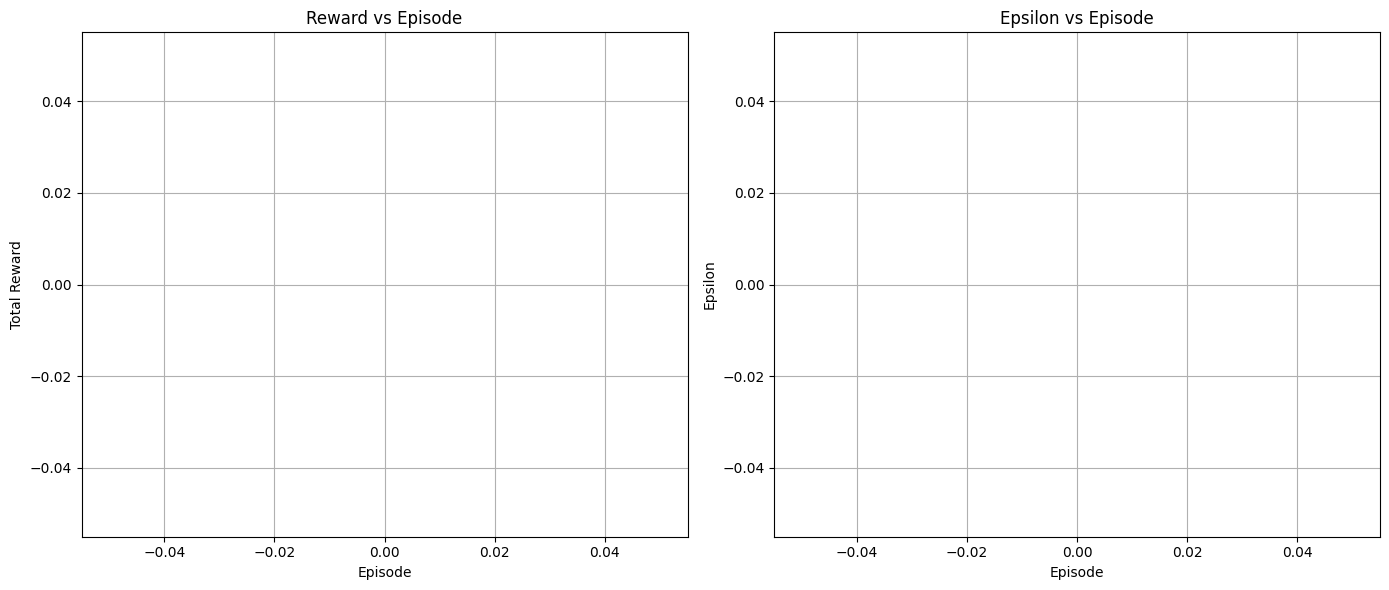

In [10]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load the text file
log_path = Path("tmp.txt")
with open(log_path, "r") as f:
    lines = f.readlines()

# Extract Episode, Reward, and Epsilon using regex
data = []
pattern = re.compile(r"Episode (\d+)/\d+, Reward: ([\-\d\.]+), Eps: ([\d\.]+)")
for line in lines:
    match = pattern.search(line)
    if match:
        episode = int(match.group(1))
        reward = float(match.group(2))
        epsilon = float(match.group(3))
        data.append((episode, reward, epsilon))

# Create a DataFrame
df = pd.DataFrame(data, columns=["Episode", "Reward", "Epsilon"])

# Plotting
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(df["Episode"], df["Reward"], label="Reward", color="blue")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward vs Episode")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(df["Episode"], df["Epsilon"], label="Epsilon", color="green")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon vs Episode")
plt.grid(True)

plt.tight_layout()
plt.show()


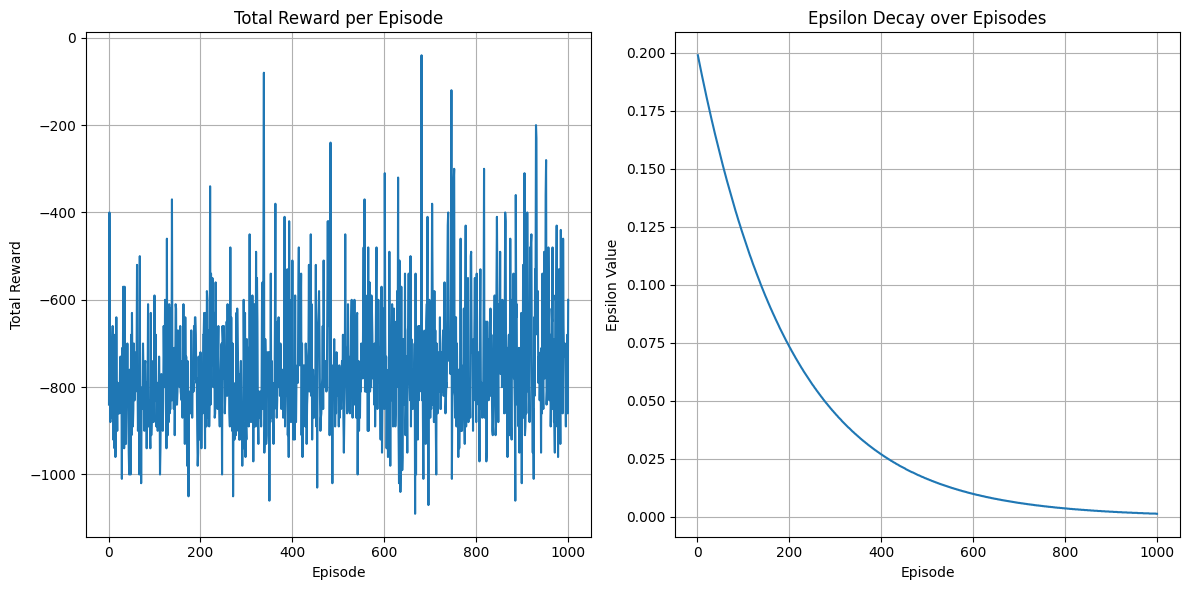

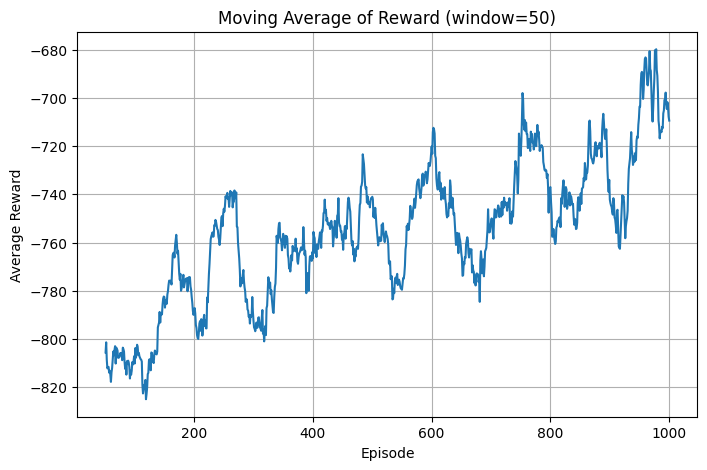

In [11]:
import matplotlib.pyplot as plt
import re

# Parse the log data from file
episodes = []
rewards = []
epsilons = []

# Regular expression to extract the numbers
pattern = r'Episode (\d+)/\d+  Total Reward: ([-]?\d+\.\d+)  Epsilon: (\d+\.\d+)'

with open('tmp.txt', 'r') as f:
    for line in f:
        if line.strip() == '':
            continue
        match = re.search(pattern, line)
        if match:
            episodes.append(int(match.group(1)))
            rewards.append(float(match.group(2)))
            epsilons.append(float(match.group(3)))

# Create the plots
plt.figure(figsize=(12, 6))

# Plot 1: Total Reward over episodes
plt.subplot(1, 2, 1)
plt.plot(episodes, rewards)
plt.title('Total Reward per Episode')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)

# Plot 2: Epsilon over episodes
plt.subplot(1, 2, 2)
plt.plot(episodes, epsilons)
plt.title('Epsilon Decay over Episodes')
plt.xlabel('Episode')
plt.ylabel('Epsilon Value')
plt.grid(True)

plt.tight_layout()
plt.show()

# Optional: Plot a moving average of rewards
window_size = 50  # Adjust this for smoother or more responsive averaging
moving_avg = [sum(rewards[i-window_size:i])/window_size 
              for i in range(window_size, len(rewards))]

plt.figure(figsize=(8, 5))
plt.plot(episodes[window_size:], moving_avg)
plt.title(f'Moving Average of Reward (window={window_size})')
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.grid(True)
plt.show()

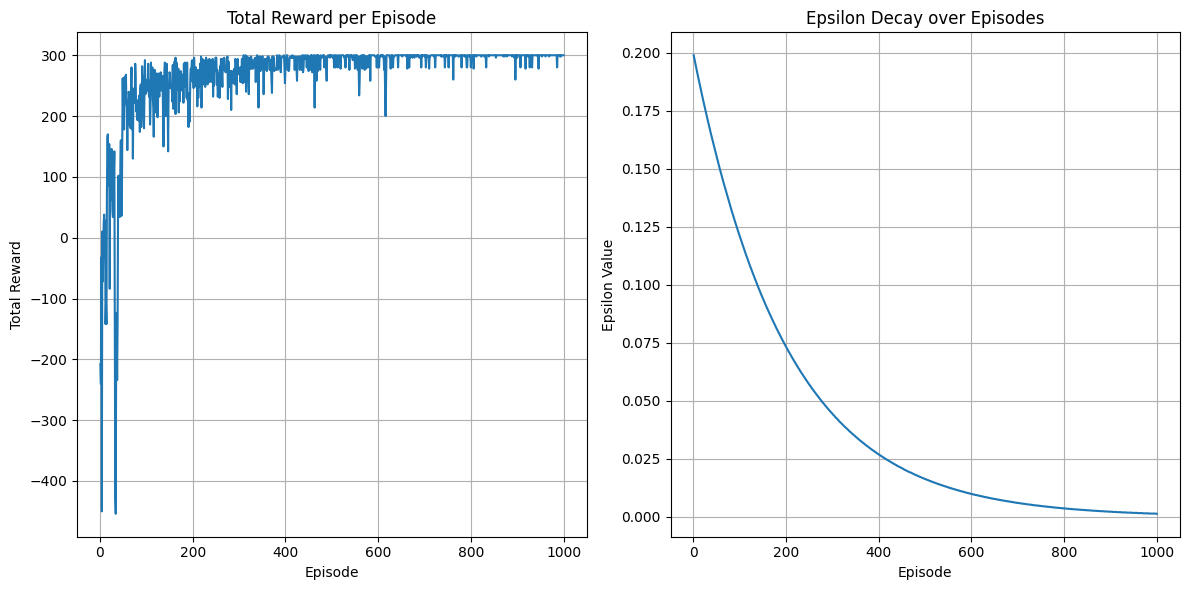

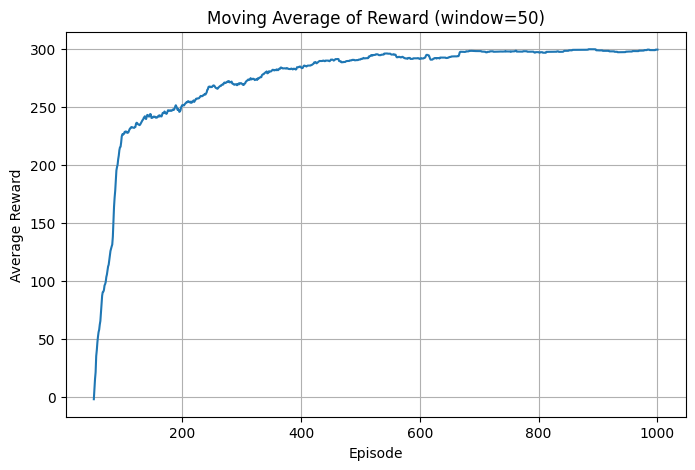

In [12]:
import matplotlib.pyplot as plt
import re

# Parse the log data from file
episodes = []
rewards = []
epsilons = []

# Regular expression to extract the numbers
pattern = r'Episode (\d+)/\d+  Total Reward: ([-]?\d+\.\d+)  Epsilon: (\d+\.\d+)'

with open('tmp.txt', 'r') as f:
    for line in f:
        if line.strip() == '':
            continue
        match = re.search(pattern, line)
        if match:
            episodes.append(int(match.group(1)))
            rewards.append(float(match.group(2)))
            epsilons.append(float(match.group(3)))

# Create the plots
plt.figure(figsize=(12, 6))

# Plot 1: Total Reward over episodes
plt.subplot(1, 2, 1)
plt.plot(episodes, rewards)
plt.title('Total Reward per Episode')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)

# Plot 2: Epsilon over episodes
plt.subplot(1, 2, 2)
plt.plot(episodes, epsilons)
plt.title('Epsilon Decay over Episodes')
plt.xlabel('Episode')
plt.ylabel('Epsilon Value')
plt.grid(True)

plt.tight_layout()
plt.show()

# Optional: Plot a moving average of rewards
window_size = 50  # Adjust this for smoother or more responsive averaging
moving_avg = [sum(rewards[i-window_size:i])/window_size 
              for i in range(window_size, len(rewards))]

plt.figure(figsize=(8, 5))
plt.plot(episodes[window_size:], moving_avg)
plt.title(f'Moving Average of Reward (window={window_size})')
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.grid(True)
plt.show()